In [1]:
# code made specifically for HellBender cluster fitting
import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

# path to JADES catalog on HellBender 
cat_name = '/home/caltech-msanche3/data/JADES_fits_data.fits'

# path to translate file on HellBender
trans_file = '/home/caltech-msanche3/data'

jades_table = Table.read(cat_name, hdu='KRON_CONV',format='fits')

for col in jades_table.colnames:
    if '_KRON' in col or '_ei' in col:
        jades_table[col] = jades_table[col] * 0.001

params = {}

# 1. Tell it where your data is
params['CATALOG_FILE'] = jades_table
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['IGM_SCALE_TAU'] = 1.0

# 2. Tell it what templates to use to fit the light
params['TEMPLATES_FILE'] = "/home/caltech-msanche3/.conda/envs/eazyenv/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/spline_templates_v2/tweak_spline.param"

# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
params['MAIN_OUTPUT_FILE'] = 'jades_run_spline_2'

# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file.csv'
self = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)

Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 304366
F070W_KRON F070W_KRON_ei (362): jwst_nircam_f070w
F090W_KRON F090W_KRON_ei (363): jwst_nircam_f090w
F105W_KRON F105W_KRON_ei (202): hst/wfc3/IR/f105w.dat
F115W_KRON F115W_KRON_ei (364): jwst_nircam_f115w
F125W_KRON F125W_KRON_ei (203): hst/wfc3/IR/f125w.dat
F140W_KRON F140W_KRON_ei (204): hst/wfc3/IR/f140w.dat
F150W_KRON F150W_KRON_ei (365): jwst_nircam_f150w
F160W_KRON F160W_KRON_ei (205): hst/wfc3/IR/f160w.dat
F162M_KRON F162M_KRON_ei (369): jwst_nircam_f162m
F182M_KRON F182M_KRON_ei (370): jwst_nircam_f182m
F200W_KRON F200W_KRON_ei (366): jwst_nircam_f200w
F210M_KRON F210M_KRON_ei (371): jwst_nircam_f210m
F250M_KRON F250M_KRON_ei (379): jwst_nircam_f250m
F277W_KRON F277W_KRON_ei (375): jwst_nircam_f277w
F300M_KRON F300M_KRON_ei (380): jwst_nircam_f300m
F335M_KRON F335M_KRON_ei (381): jwst_nircam_f3

Set sys_err = 0.01 (positive=True)
Template grid: /home/caltech-msanche3/.conda/envs/eazyenv/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/spline_templates_v2/tweak_spline.param (this may take some time)


100%|██████████| 20/20 [01:21<00:00,  4.10s/it]


Template   0: tweak_spline_age0.01_av0.0.fits (NZ=26).
Template   1: tweak_spline_age0.01_av0.5.fits (NZ=26).
Template   2: tweak_spline_age0.03_av0.0.fits (NZ=26).
Template   3: tweak_spline_age0.03_av0.5.fits (NZ=26).
Template   4: tweak_spline_age0.03_av1.0.fits (NZ=26).
Template   5: tweak_spline_age0.03_av2.0.fits (NZ=26).
Template   6: tweak_spline_age0.03_av3.0.fits (NZ=26).
Template   7: tweak_spline_age0.03_av5.0.fits (NZ=26).
Template   8: tweak_spline_age0.16_av0.0.fits (NZ=1).
Template   9: tweak_spline_age0.16_av1.0.fits (NZ=1).
Template  10: tweak_spline_age0.16_av2.0.fits (NZ=1).
Template  11: tweak_spline_age0.67_av0.0.fits (NZ=1).
Template  12: tweak_spline_age0.67_av1.0.fits (NZ=1).
Template  13: tweak_spline_age0.67_av2.0.fits (NZ=1).
Template  14: tweak_spline_age1.75_av0.0.fits (NZ=1).
Template  15: tweak_spline_age1.75_av1.0.fits (NZ=1).
Template  16: tweak_spline_age3.68_av0.0.fits (NZ=1).
Template  17: tweak_spline_age3.68_av1.0.fits (NZ=1).
Template  18: tweak_

256it [00:49,  5.21it/s]


In [14]:
# path to JADES catalog on HellBender 
cat_name = '/home/caltech-msanche3/data/JADES_fits_data.fits'

# path to translate file on HellBender
trans_file = '/home/caltech-msanche3/data'

jades_table = Table.read(cat_name, hdu='KRON_CONV',format='fits')

for col in jades_table.colnames:
    if '_KRON' in col or '_ei' in col:
        jades_table[col] = jades_table[col] * 0.001

print(jades_table[55102])

  ID       RA       DEC             A_KRON                B_KRON          THETA_KRON       F070W_KRON           F070W_KRON_e        F070W_KRON_ei         F070W_KRON_bkg           A_KRON_S              B_KRON_S        THETA_KRON_S     F070W_KRON_S         F070W_KRON_S_e       F070W_KRON_S_ei       F070W_KRON_S_bkg        F090W_KRON          F090W_KRON_e         F090W_KRON_ei         F090W_KRON_bkg         F090W_KRON_S        F090W_KRON_S_e       F090W_KRON_S_ei        F090W_KRON_S_bkg         F105W_KRON          F105W_KRON_e        F105W_KRON_ei         F105W_KRON_bkg        F105W_KRON_S        F105W_KRON_S_e      F105W_KRON_S_ei       F105W_KRON_S_bkg         F115W_KRON          F115W_KRON_e         F115W_KRON_ei         F115W_KRON_bkg        F115W_KRON_S         F115W_KRON_S_e       F115W_KRON_S_ei       F115W_KRON_S_bkg         F125W_KRON          F125W_KRON_e        F125W_KRON_ei         F125W_KRON_bkg        F125W_KRON_S        F125W_KRON_S_e      F125W_KRON_S_ei       F125W_KRON_S

In [2]:
self.set_sys_err(positive=True) # should I change this to False?
# total objs: 304366
obj = 60000
# 2. Fit the ENTIRE catalog
print('Fitting catalog in chunks...')
# total objects: 304366
# split into chunks of 50000
chunk_size = 50000
for i in range(0, obj, chunk_size):
    print(f'Fitting chunk {i//chunk_size + 1}...')
    chunk = self.idx[i : i + chunk_size]
    self.fit_catalog(chunk,n_proc=16)

print('Catalog fitted successfully!')

Set sys_err = 0.01 (positive=True)
Fitting catalog in chunks...
Fitting chunk 1...


100%|██████████| 256/256 [01:06<00:00,  3.85it/s]


Compute best fits
fit_best: 2.2 s (n_proc=4,  NOBJ=48266)
Fit 70.0 s (n_proc=16, NOBJ=50000)
Fitting chunk 2...


100%|██████████| 256/256 [01:05<00:00,  3.88it/s]


Compute best fits
fit_best: 2.6 s (n_proc=9,  NOBJ=95985)
Fit 70.5 s (n_proc=16, NOBJ=50000)
Catalog fitted successfully!


In [3]:
# Derived parameters (z params, RF colors, masses, SFR, etc.)


zout, hdu = self.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)

# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

Get best fit coeffs & best redshifts
fit_best: 8.4 s (n_proc=9,  NOBJ=95985)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


  3%|▎         | 2902/95985 [00:12<06:36, 234.76it/s]/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:6511: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  draws = np.random.multivariate_normal(
100%|██████████| 95985/95985 [06:49<00:00, 234.23it/s]


called spine templates


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4287: RuntimeWarning: invalid value encountered in divide
  coeffs_norm = (coeffs_norm.T/coeffs_norm.sum(axis=1)).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/astropy/units/quantity.py:676: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4322: RuntimeWarning: invalid value encountered in divide
  draws_norm = (draws_norm.T/draws_norm.sum(axis=2).T).T
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/photoz.py:4652: RuntimeWarning: invalid value encountered in divide
  par_draws_table['ssfr'] = (par_draws_table['sfr'] /


  id       ra       dec     nusefilt    z_ml   z_ml_chi2  z_ml_risk   lc_min  lc_max   z_phot  z_phot_chi2 z_phot_risk  z_min_risk   min_risk   z_raw_chi2 raw_chi2   z025     z160     z500     z840     z975   restU restU_err restB restB_err restV restV_err restJ restJ_err    dL     mass       sfr         Lv      LIR    energy_abs       MLv         Av         mass_p            sfr_p              Lv_p                LIR_p             energy_abs_p         Av_p            ssfr_p       
          deg       deg                                                                                                                                                                                                                                                            Mpc   solMass  solMass / yr  solLum   solLum    solLum   solMass / solLum                                                                                                                                          
------ --------- ---------

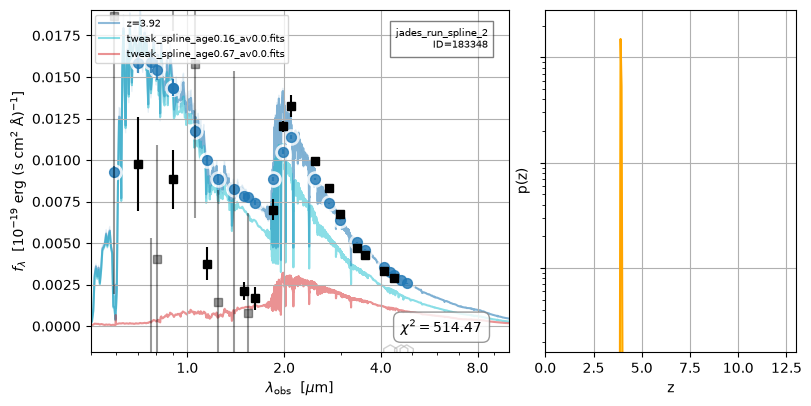

In [13]:
# Show brightest objects with z_spec > 1
ifilter = self.flux_columns[np.argmin((self.lc - 8140)**2)]
'''
imag = 31.40 - 2.5*np.log10(ez.cat[ifilter])
#sel = (ez.ZPHOTO > 12)

dat1 = '/home/caltech-msanche3/data/jades_eazy_output/different_fitting_runs/jades_run_60k_fit.data.fits'
hdul3 = fits.open(dat1,memap=True)
zbest = hdul3[1].data
sel = zbest > 0

so = np.argsort(imag[sel])
ids = ez.OBJID[sel][so]


for i in range(15):
    fig, data = ez.show_fit(ids[15+i], xlim=[0.2, 6], show_components=True,
                              logpz=True, zr=[0,13])
'''
objs = [10996, 75654, 77159, 110748, 165595, 176748, 195914, 452238, 
        460029, 463268, 463518, 466823, 467144, 468018, 469153, 470387, 
        474185, 507236]
highz_objs = [809545, 809593, 809648,809672,809777,183348]
# pass ID where ids[i] was previously passed
print(zout[55102])
'''
for obj in highz_objs:
    fig, data = self.show_fit(obj, xlim=[0.5, 10], show_components=True,
                        logpz=True, zr=[0,13])
'''
fig, data = self.show_fit(183348, xlim=[0.5, 10], show_components=True,
                        logpz=True, zr=[0,13])

# 2. Get the current axes from the figure
ax = fig.gca()

# 3. Define your custom text
box_text = r"$\chi^2 =  514.47$"

# 4. Add the text box to the bottom right
ax.text(
    -0.25, 0.05,                  # X, Y coordinates in axes fraction (95% right, 5% up)
    box_text, 
    transform=ax.transAxes,      # Critically important: binds coords to the plot box size, not data
    horizontalalignment='right', # Aligns the text edge flush right
    verticalalignment='bottom',  # Aligns the text edge flush bottom
    fontsize=10, 
    bbox=dict(                   # Defines the background box properties
        boxstyle='round,pad=0.5', 
        facecolor='white', 
        edgecolor='gray', 
        alpha=0.8
    )
)

# 5. Redraw/show the modified figure if needed
fig.canvas.draw()
